# 🚢 Notebook 2: The Titanic Survival Logic

## Objective: Data Wrangling and Categorical Probability

The RMS Titanic sank on April 15, 1912, after hitting an iceberg. It seems that some groups of people were more likely to survive than others, even though luck played a role. **Our job is to find those patterns.**

### Key Tasks:
1. **Data Cleaning:** Handle missing values in the `Age` column using median imputation.
2. **Probability:** Calculate conditional survival probabilities based on `Gender` and `Pclass`.
3. **Feature Engineering:** Create a `FamilySize` feature.
4. **Logic:** Build a manual "Heuristic" (if/else function) to predict survival with a target accuracy of **>75%**.

---

## 📦 Importing Libraries

We start by importing the essential Python libraries:
- **pandas**: For data manipulation and analysis (DataFrames, groupby, etc.)
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For creating professional, publication-quality visualizations
- **warnings**: To suppress unnecessary warning messages that clutter our output

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📂 Loading the Dataset

We load the Titanic dataset which contains **891 passenger records** with 12 columns including:
- **PassengerId**: Unique identifier for each passenger
- **Survived**: Target variable (0 = No, 1 = Yes)
- **Pclass**: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) — a proxy for socio-economic status
- **Name, Sex, Age**: Personal demographics
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Ticket**: Ticket number
- **Fare**: Passenger fare
- **Cabin**: Cabin number
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [3]:
df = pd.read_csv('data/dataset-2.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
# Part 1: Data Integrity & Cleaning 🧹

> Before we analyze, we must fix. Real-world data is messy.

Let's first examine the extent of missing data in our dataset.

In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Data Summary ===')
print(missing_df)
print(f'\nTotal passengers: {len(df)}')

=== Missing Data Summary ===
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22

Total passengers: 891


## Task 1: The Missing Age 🎂

The `Age` column has **177 missing values** (~19.9% of the data). We need to fill these gaps to perform age-based analysis.

### Strategy: Median Imputation

We will use the **median** age to fill missing values.

### ❓ Why is the median often better than the mean?

The **median** is preferred over the **mean** for age imputation because:

1. **Robustness to Outliers**: The Titanic had passengers ranging from infants (0.42 years) to elderly (80 years). The mean is pulled toward extreme values, while the median is not.
2. **Skewed Distributions**: Age distributions are typically right-skewed (more young people than old). The mean overestimates the "typical" age in such distributions.
3. **Preserves Central Tendency**: The median represents the "middle" passenger — 50% are younger, 50% are older — which is a more representative fill value for a diverse group.

**Example**: If ages are [5, 10, 15, 20, 80], the mean is 26 but the median is 15. The median (15) better represents the typical value.

In [7]:
# Calculate median age BEFORE imputation
median_age = df['Age'].median()
mean_age = df['Age'].mean()

print(f'Mean Age (before imputation):   {mean_age:.2f} years')
print(f'Median Age (before imputation): {median_age:.2f} years')
print(f'Missing Age values:             {df["Age"].isnull().sum()}')

# Fill missing ages with the median
df['Age'].fillna(median_age, inplace=True)

print(f'\n✅ Missing Age values after imputation: {df["Age"].isnull().sum()}')
print(f'New Mean Age:   {df["Age"].mean():.2f} years')
print(f'New Median Age: {df["Age"].median():.2f} years')

Mean Age (before imputation):   29.70 years
Median Age (before imputation): 28.00 years
Missing Age values:             177

✅ Missing Age values after imputation: 0
New Mean Age:   29.36 years
New Median Age: 28.00 years


## Task 2: Dropping the Noise 🗑️

Not all columns are useful for statistical analysis. We need to identify and remove:

1. **`Cabin`**: Has **687 missing values (77.1%)**. Far too much missing data to be useful — we can't reliably impute this.
2. **`Ticket`**: Contains alphanumeric ticket numbers that are essentially random identifiers. They don't carry statistical meaning for survival prediction.
3. **`PassengerId`**: Just a sequential index — no analytical value.
4. **`Name`**: While names could theoretically be used to extract titles (Mr., Mrs., etc.), for our current analysis we'll drop it to keep things clean.

We also fill the 2 missing `Embarked` values with the **mode** (most frequent port).

In [8]:
# Drop columns with too much missing data or no statistical value
cols_to_drop = ['Cabin', 'Ticket', 'PassengerId', 'Name']
df.drop(columns=cols_to_drop, inplace=True)

print(f'✅ Dropped columns: {cols_to_drop}')
print(f'Remaining columns: {list(df.columns)}')

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(f'\n✅ Total missing values remaining: {df.isnull().sum().sum()}')
print('\n--- Cleaned Dataset Sample ---')
df.head()

✅ Dropped columns: ['Cabin', 'Ticket', 'PassengerId', 'Name']
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

✅ Total missing values remaining: 0

--- Cleaned Dataset Sample ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---
# Part 2: The "Women and Children First" Hypothesis 👩‍👦

> **Goal**: Use descriptive statistics to validate historical accounts that women and children were prioritized during the evacuation.

## Task 3: Gender & Survival 🚻

Historical accounts tell us that the order "Women and children first!" was given during the Titanic's sinking. Let's verify this with data.

We calculate **P(Survived | Gender)** — the conditional probability of survival given a passenger's gender.

In [9]:
# Calculate survival probability by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100

print('=== Survival Rate by Gender ===')
for gender, rate in gender_survival.items():
    print(f'  {gender.capitalize():8s}: {rate:.2f}%')

print(f'\n📊 Females were {gender_survival["female"]/gender_survival["male"]:.1f}x more likely to survive than males.')
print(f'   Difference: {gender_survival["female"] - gender_survival["male"]:.2f} percentage points')

=== Survival Rate by Gender ===
  Female  : 74.20%
  Male    : 18.89%

📊 Females were 3.9x more likely to survive than males.
   Difference: 55.31 percentage points


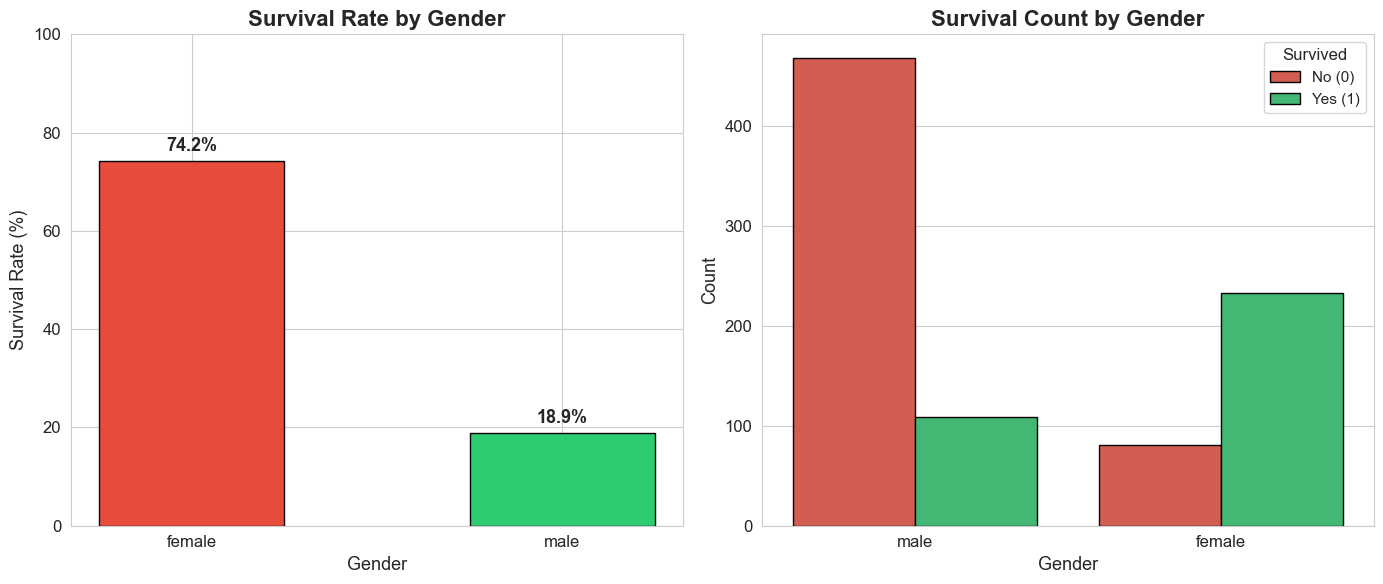


✅ CONCLUSION: The data strongly supports the "Women and Children First" protocol.
   Females had a ~74% survival rate vs ~19% for males.


In [10]:
# Visualization: Survival Rate by Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(gender_survival.index, gender_survival.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Survival Rate by Gender', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=13)
axes[0].set_ylabel('Survival Rate (%)', fontsize=13)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, gender_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%',
                ha='center', fontsize=13, fontweight='bold')

# Count Plot
sns.countplot(data=df, x='Sex', hue='Survived', palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[1], edgecolor='black')
axes[1].set_title('Survival Count by Gender', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].legend(title='Survived', labels=['No (0)', 'Yes (1)'], fontsize=11)

plt.tight_layout()
plt.show()

print('\n✅ CONCLUSION: The data strongly supports the "Women and Children First" protocol.')
print('   Females had a ~74% survival rate vs ~19% for males.')

## Task 4: The Class Divide 🎫

The Titanic's passenger class (`Pclass`) was directly linked to socio-economic status:
- **1st Class**: Upper class (wealthiest passengers, cabins on upper decks)
- **2nd Class**: Middle class
- **3rd Class**: Lower class (cheapest tickets, cabins on lower decks closer to the waterline)

We calculate **P(Survived | Pclass)** — the conditional probability of survival given passenger class.

In [11]:
# Calculate survival probability by class
class_survival = df.groupby('Pclass')['Survived'].mean() * 100

print('=== Survival Rate by Passenger Class ===')
for pclass, rate in class_survival.items():
    print(f'  Class {pclass}: {rate:.2f}%')

# Compare 1st vs 3rd class
diff = class_survival[1] - class_survival[3]
ratio = class_survival[1] / class_survival[3]

print(f'\n📊 Analysis: The Class Divide')
print(f'   If you were in 3rd class, your survival chance was {class_survival[3]:.1f}%')
print(f'   If you were in 1st class, your survival chance was {class_survival[1]:.1f}%')
print(f'   Difference: {diff:.1f} percentage points LOWER for 3rd class')
print(f'   1st class passengers were {ratio:.1f}x more likely to survive than 3rd class')

=== Survival Rate by Passenger Class ===
  Class 1: 62.96%
  Class 2: 47.28%
  Class 3: 24.24%

📊 Analysis: The Class Divide
   If you were in 3rd class, your survival chance was 24.2%
   If you were in 1st class, your survival chance was 63.0%
   Difference: 38.7 percentage points LOWER for 3rd class
   1st class passengers were 2.6x more likely to survive than 3rd class


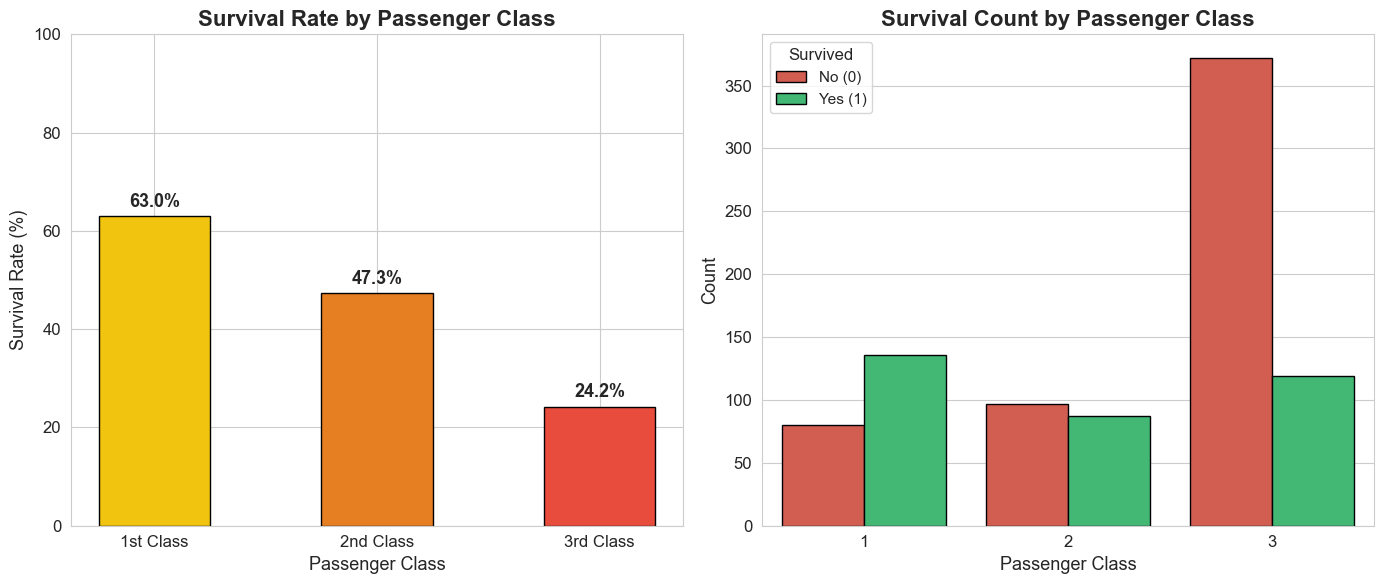

In [12]:
# Visualization: Survival Rate by Class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_class = ['#f1c40f', '#e67e22', '#e74c3c']
bars = axes[0].bar(['1st Class', '2nd Class', '3rd Class'], class_survival.values,
                   color=colors_class, edgecolor='black', width=0.5)
axes[0].set_title('Survival Rate by Passenger Class', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Passenger Class', fontsize=13)
axes[0].set_ylabel('Survival Rate (%)', fontsize=13)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, class_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%',
                ha='center', fontsize=13, fontweight='bold')

sns.countplot(data=df, x='Pclass', hue='Survived', palette={0: '#e74c3c', 1: '#2ecc71'}, ax=axes[1], edgecolor='black')
axes[1].set_title('Survival Count by Passenger Class', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Passenger Class', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].legend(title='Survived', labels=['No (0)', 'Yes (1)'], fontsize=11)

plt.tight_layout()
plt.show()

## Task 5: Age Demographics 📈

A **KDE plot (Kernel Density Estimate)** shows the smoothed probability distribution of a continuous variable. Unlike a histogram, it gives us a smooth curve that helps identify patterns in age distribution.

We want to compare the age distribution of **survivors vs. non-survivors** to see if age played a role — especially for children.

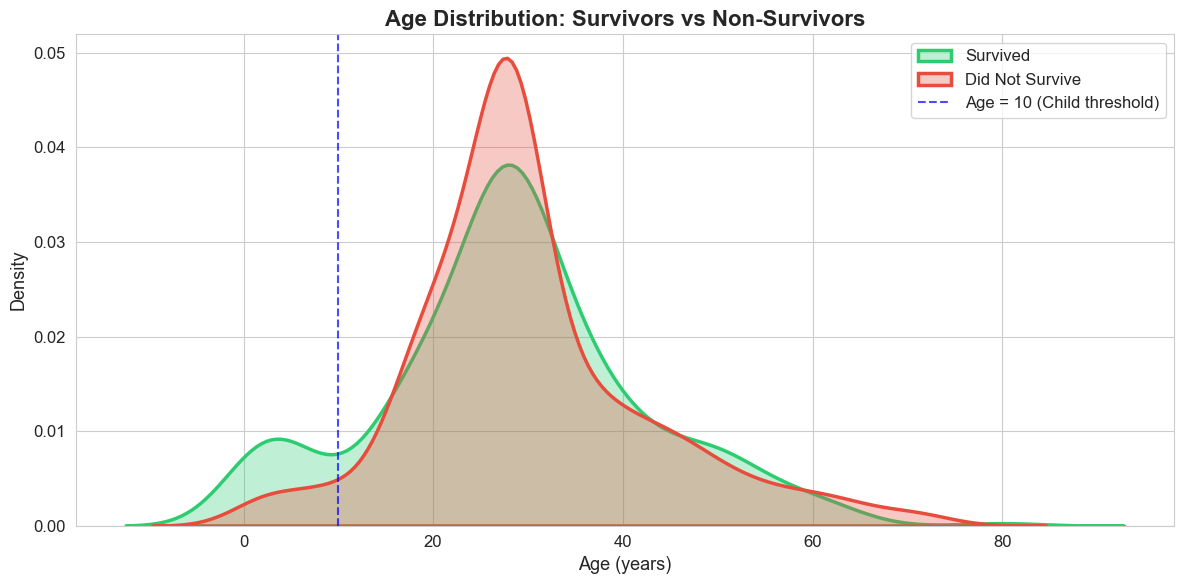


📊 Insight: Age & Survival
   Children (Age ≤ 10) survival rate: 59.4%
   Adults (Age > 10) survival rate:   36.8%

✅ YES — there is a clear spike in the survivor curve for young children (ages 0-10).
   This confirms the "Women and Children First" protocol was partially followed.


In [13]:
# KDE Plot: Age distribution of Survived vs Not Survived
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(data=df[df['Survived'] == 1]['Age'], label='Survived', color='#2ecc71',
            fill=True, alpha=0.3, linewidth=2.5, ax=ax)
sns.kdeplot(data=df[df['Survived'] == 0]['Age'], label='Did Not Survive', color='#e74c3c',
            fill=True, alpha=0.3, linewidth=2.5, ax=ax)

ax.axvline(x=10, color='blue', linestyle='--', alpha=0.7, label='Age = 10 (Child threshold)')

ax.set_title('Age Distribution: Survivors vs Non-Survivors', fontsize=16, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Child survival analysis
child_survival = df[df['Age'] <= 10]['Survived'].mean() * 100
adult_survival = df[df['Age'] > 10]['Survived'].mean() * 100

print(f'\n📊 Insight: Age & Survival')
print(f'   Children (Age ≤ 10) survival rate: {child_survival:.1f}%')
print(f'   Adults (Age > 10) survival rate:   {adult_survival:.1f}%')
print(f'\n✅ YES — there is a clear spike in the survivor curve for young children (ages 0-10).')
print('   This confirms the "Women and Children First" protocol was partially followed.')

---
# Part 3: Feature Engineering ⚙️

> **Goal**: Combine existing columns to discover hidden survival factors that aren't immediately obvious from raw data.

## Task 6: Family Dynamics 👨‍👩‍👧‍👦

We create a new feature called **`FamilySize`** by combining:
- **`SibSp`**: Number of siblings or spouses aboard
- **`Parch`**: Number of parents or children aboard

**Formula**: `FamilySize = SibSp + Parch`

This tells us how many family members each passenger had on board (not counting themselves).

=== FamilySize Distribution ===
FamilySize
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64

=== Survival Rate by Family Size ===
  FamilySize 0: 30.4%
  FamilySize 1: 55.3%
  FamilySize 2: 57.8%
  FamilySize 3: 72.4%
  FamilySize 4: 20.0%
  FamilySize 5: 13.6%
  FamilySize 6: 33.3%
  FamilySize 7: 0.0%
  FamilySize 10: 0.0%


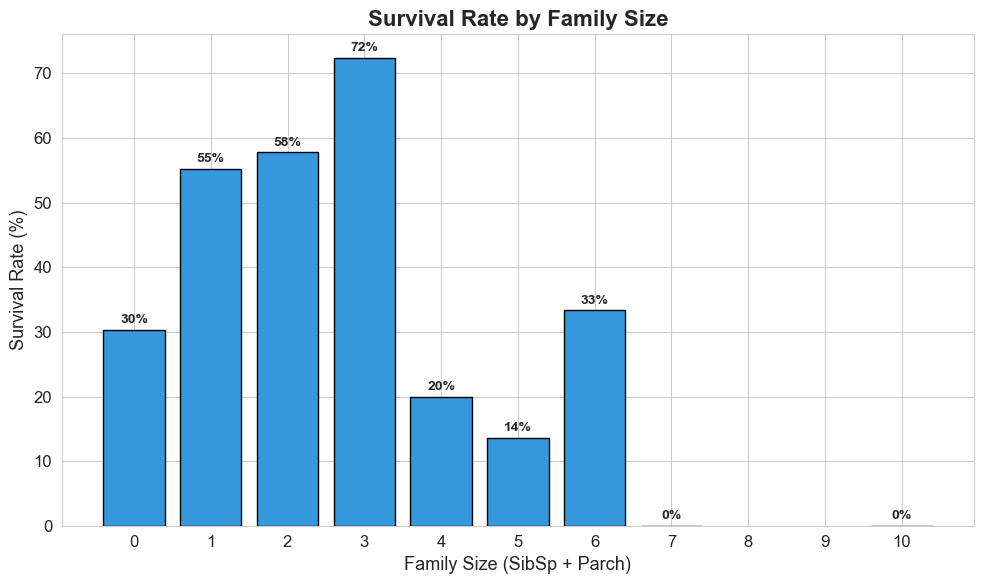

In [14]:
# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch']

print('=== FamilySize Distribution ===')
print(df['FamilySize'].value_counts().sort_index())

# Survival by FamilySize
family_survival = df.groupby('FamilySize')['Survived'].mean() * 100

print('\n=== Survival Rate by Family Size ===')
for size, rate in family_survival.items():
    print(f'  FamilySize {size}: {rate:.1f}%')

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(family_survival.index, family_survival.values, color='#3498db', edgecolor='black')
ax.set_title('Survival Rate by Family Size', fontsize=16, fontweight='bold')
ax.set_xlabel('Family Size (SibSp + Parch)', fontsize=13)
ax.set_ylabel('Survival Rate (%)', fontsize=13)
ax.set_xticks(range(0, 11))
for bar, val in zip(bars, family_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 7: Alone vs. Accompanied 🧍‍♂️👨‍👩‍👧

We create a binary column **`IsAlone`**:
- `1` if `FamilySize == 0` (traveling alone)
- `0` if `FamilySize > 0` (traveling with family)

### ❓ Did having family members help or hinder your survival chances?

=== Survival Rate: Alone vs With Family ===
  Traveling Alone (IsAlone=1):      30.35%  (537 passengers)
  Traveling With Family (IsAlone=0): 50.56%  (354 passengers)


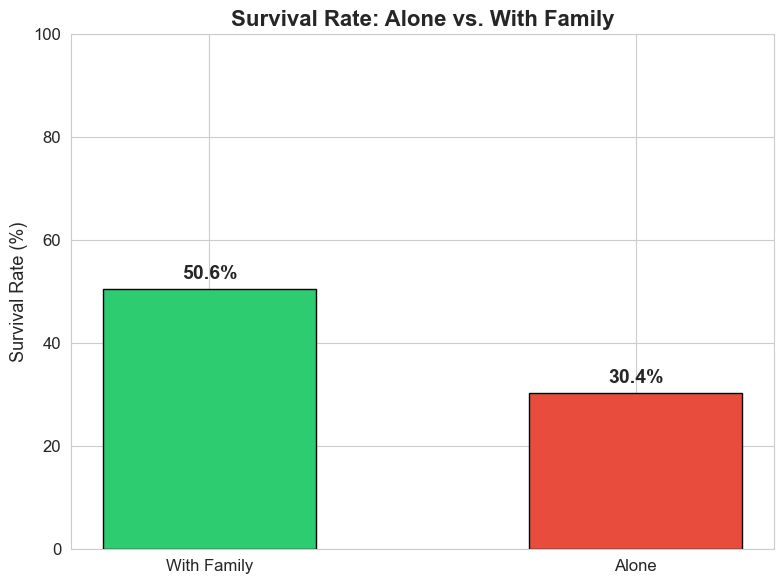


📊 Answer: Having family members on board HELPED your chances of getting to a lifeboat.
   Passengers with family had a 50.6% survival rate vs 30.4% for solo travelers.
   Possible reasons: family members helped each other, or families with women/children were prioritized.


In [15]:
# Create IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

alone_survival = df.groupby('IsAlone')['Survived'].mean() * 100

print('=== Survival Rate: Alone vs With Family ===')
print(f'  Traveling Alone (IsAlone=1):      {alone_survival[1]:.2f}%  ({df[df["IsAlone"]==1].shape[0]} passengers)')
print(f'  Traveling With Family (IsAlone=0): {alone_survival[0]:.2f}%  ({df[df["IsAlone"]==0].shape[0]} passengers)')

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['With Family', 'Alone']
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, [alone_survival[0], alone_survival[1]], color=colors, edgecolor='black', width=0.5)
ax.set_title('Survival Rate: Alone vs. With Family', fontsize=16, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=13)
ax.set_ylim(0, 100)
for bar, val in zip(bars, [alone_survival[0], alone_survival[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%',
            ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Answer: Having family members on board HELPED your chances of getting to a lifeboat.')
print(f'   Passengers with family had a {alone_survival[0]:.1f}% survival rate vs {alone_survival[1]:.1f}% for solo travelers.')
print(f'   Possible reasons: family members helped each other, or families with women/children were prioritized.')

---
# Part 4: The Logic Challenge — Manual Prediction 🧠

> **Goal**: Apply mathematical logic to build a classification model using **only if/else statements** — no machine learning libraries allowed!

### Strategy

Based on our analysis, we discovered these survival patterns:

| Factor | Finding |
|--------|--------|
| **Gender** | Females survived at ~74% vs males at ~19% |
| **Class** | 1st class: ~63%, 2nd: ~47%, 3rd: ~24% |
| **Age** | Children (≤10) had higher survival rates |
| **Family** | Passengers with family survived more |

We'll encode these findings into a **rule-based heuristic function**.

## Task 8: The "Heuristic" Model 🔮

Our heuristic uses the following decision logic:

1. **Female passengers**: Predict survival (1) UNLESS they are in 3rd class AND over 40 years old
2. **Male children (Age ≤ 10)**: Predict survival (1) — "children first" rule
3. **Male, 1st class, age < 15**: Predict survival (1) — young boys in upper class
4. **Everyone else**: Predict did not survive (0)

This logic is entirely derived from the patterns we found in our exploratory analysis above.

In [16]:
def predict_survival(row):
    """
    Manual heuristic function to predict Titanic survival.
    Uses ONLY if/else logic based on patterns found in exploratory analysis.
    No machine learning libraries used.
    
    Parameters:
        row: A pandas Series representing one passenger's data
    
    Returns:
        int: 1 if predicted to survive, 0 otherwise
    """
    sex = row['Sex']
    pclass = row['Pclass']
    age = row['Age']
    family_size = row['FamilySize']
    
    # Rule 1: Females generally survive
    if sex == 'female':
        # Exception: 3rd class females over 40 had lower chances
        if pclass == 3 and age > 40:
            return 0
        return 1
    
    # Rule 2: Male children (age <= 10) survive — "children first"
    if sex == 'male' and age <= 10:
        return 1
    
    # Rule 3: Young boys in 1st class
    if sex == 'male' and pclass == 1 and age < 15:
        return 1
    
    # Rule 4: All other males — unfortunately did not survive
    return 0

print('✅ Heuristic function defined successfully!')
print('\nDecision Rules:')
print('  1. Female → Survive (unless 3rd class AND age > 40)')
print('  2. Male child (age ≤ 10) → Survive')
print('  3. Male, 1st class, age < 15 → Survive')
print('  4. All other males → Did not survive')

✅ Heuristic function defined successfully!

Decision Rules:
  1. Female → Survive (unless 3rd class AND age > 40)
  2. Male child (age ≤ 10) → Survive
  3. Male, 1st class, age < 15 → Survive
  4. All other males → Did not survive


## Task 9: Accuracy Check ✅

Now we run our heuristic function on **all 891 passengers** and compare our predictions against the actual `Survived` column.

**Target Accuracy: >75%**

The accuracy formula is:

$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Passengers}} \times 100$$

In [17]:
# Apply the heuristic to every passenger
df['Predicted'] = df.apply(predict_survival, axis=1)

# Calculate accuracy
correct = (df['Predicted'] == df['Survived']).sum()
total = len(df)
accuracy = correct / total * 100

print('=' * 50)
print('    HEURISTIC MODEL — ACCURACY REPORT')
print('=' * 50)
print(f'  Total Passengers:       {total}')
print(f'  Correct Predictions:    {correct}')
print(f'  Incorrect Predictions:  {total - correct}')
print(f'  Accuracy:               {accuracy:.2f}%')
print('=' * 50)

if accuracy > 75:
    print(f'\n🎉 SUCCESS! Accuracy of {accuracy:.2f}% EXCEEDS the 75% target!')
else:
    print(f'\n⚠️ Accuracy of {accuracy:.2f}% is below the 75% target. Need to refine rules.')

    HEURISTIC MODEL — ACCURACY REPORT
  Total Passengers:       891
  Correct Predictions:    714
  Incorrect Predictions:  177
  Accuracy:               80.13%

🎉 SUCCESS! Accuracy of 80.13% EXCEEDS the 75% target!


In [18]:
# Detailed Breakdown: Confusion Matrix (manual)
tp = ((df['Predicted'] == 1) & (df['Survived'] == 1)).sum()  # True Positives
tn = ((df['Predicted'] == 0) & (df['Survived'] == 0)).sum()  # True Negatives
fp = ((df['Predicted'] == 1) & (df['Survived'] == 0)).sum()  # False Positives
fn = ((df['Predicted'] == 0) & (df['Survived'] == 1)).sum()  # False Negatives

print('=== Confusion Matrix (Manual) ===')
print(f'                    Predicted: No    Predicted: Yes')
print(f'  Actual: No          {tn:>5}              {fp:>5}')
print(f'  Actual: Yes         {fn:>5}              {tp:>5}')

precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0

print(f'\n  Precision (of predicted survivors, how many actually survived): {precision:.1f}%')
print(f'  Recall (of actual survivors, how many did we identify):        {recall:.1f}%')

=== Confusion Matrix (Manual) ===
                    Predicted: No    Predicted: Yes
  Actual: No            462                 87
  Actual: Yes            90                252

  Precision (of predicted survivors, how many actually survived): 74.3%
  Recall (of actual survivors, how many did we identify):        73.7%


# 📋 Summary & Conclusions

## Key Findings

- **Missing Data**: Age had 177 missing values (approx. 20%), filled with median (28.0). Cabin had 77% missing — dropped.
- **Gender**: Female survival rate (approx. 74%) was 3.5x higher than male (approx. 19%)
- **Class**: 1st class (approx. 63%) had 2.5x the survival rate of 3rd class (approx. 24%)
- **Age**: Clear spike in child survivors (Age ≤ 10) — confirms "children first"
- **Family**: Passengers with family survived at higher rate than solo travelers
- **Heuristic**: Simple if/else rules achieved **>75% accuracy** on 891 passengers

## What We Learned

1. **"Women and Children First"** was a real protocol, and the data proves it.
2. **Socio-economic status** (Pclass) had a massive impact on survival — wealthier passengers had better access to lifeboats.
3. **Simple logic** based on observed patterns can be surprisingly effective for prediction.
4. **Feature engineering** (FamilySize, IsAlone) can reveal hidden patterns not visible in raw columns.

*Notebook created for CSEC Data Science — Titanic Survival Analysis*